# Introduction

Fix $n \in \lbrace 2, 3 \rbrace.$ The $\textbf{$n$-dimensional Rubik's Cube}$ is a cube such that each of its $6$ square faces is partitioned into $n^2$ smaller colored squares, known as $\textbf{stickers}.$ Each sticker takes one color from a set of $6$ distinct colors. We refer to a state of the cube with its $n^2$ colored stickers as a $\textbf{(colored) cube configuration}.$ 

Examples of cube configurations are shown below for $n=2,3,$ respectively.
<table><tr>
    
<td>  <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%202x2x2%201.gif" alt="Drawing" style="width: 200px;"/> <figcaption> An Arbitrary 2D Rubik's Cube Configuration </figcaption> 
<td>  <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%203x3x3%201.gif" alt="Drawing" style="width: 200px;"/> <figcaption> An Arbitrary 3D Rubik's Cube Configuration </figcaption>  </td>
</tr></table>

We refer to a $\textbf{solved configuration}$ as a configuration such that each square face has $n^2$ stickers of the same color.

Examples of solved cube configurations are shown below for $n=2,3,$ respectively.
<table><tr>
<td> <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%202x2x2%202.gif" alt="Drawing" style="width: 200px;"/> <figcaption> A Solved 2D Rubik's Cube Configuration </figcaption> 
<td> <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%203x3x3%202.gif" alt="Drawing" style="width: 200px;"/> <figcaption> A Solved 3D Rubik's Cube Configuration </figcaption> </td>
</tr></table>

For any cube configuration, we can perform a $\textbf{face rotation (scramble)}$ on it. A face rotation is either a $90$ degrees clockwise rotation or counterclockwise rotation of a particular face.

# Problem Statement

Fix a dimension $n \in \lbrace 2,3 \rbrace,$ and let $\mathcal{G}_n$ to be the set of all possible cube configurations for the $n$-dimensional Rubiks Cube. 

Given an arbitrary cube configuration $c \in \mathcal{G}_n,$ the standard challenge is to $\textbf{solve (unscramble)}$ it, which means to find a minimal number of face rotations $m_c$ needed so that we obtain a solved configuration upon performing such rotations in succession. Define $\textbf{God's number}$ for dimension $n$ to be the number $$M_n=\max_{c \in \mathcal{G}_n} m_c.$$ What is the exact value of $M_n$ ? To answer the first question, we will show how we can identify face rotations as certain permutations upon enumerating the cube stickers. We then iteratively construct the set of all possible function compositions of such permutations (which is a subgroup). The number of iterations needed to do this is precisely God's number. We then show that $\mathcal{G}_n$ can be identified with this subgroup of permutations.


Next, begin with a solved configuration of the cube, and consider the reverse process of unscrambling, namely scrambling. Let $t$ be a fixed number of face rotations made (which we refer to as $\textbf{scrambles}$). Given a configuration $c \in \mathcal{G}_n,$ what is the probability of obtaining $c$ in $t$ scrambles ? As $t$ gets larger and larger, is it possible to obtain most, if not all, configurations in $\mathcal{G}_n$ with equal probability ? To answer these questions, we interpret the process of scrambling as a Stochastic process with state space $\mathcal{G}_n.$ This process is a Markov Chain with an associated probability transition matrix. Using this matrix, for each $t \in \mathbb{N},$ we recursively compute the probability of obtaining any configuration in $\mathcal{G}_n$ in exactly $t$ scrambles. Let $\pi_t$ be the corresponding probability distribution in exactly $t$ scrambles. We measure how close $\pi_t$ is to the discrete uniform distribution $\pi_\infty$ of $\mathcal{G}_n.$ 

$\textbf{Note}:$ In order for all code cells to run without errors, please run the code cell below, which imports all the needed libraries. If a certain library fails to import, run the magic command 
<code>!pip3 install \<insert library name here\></code> in a new cell (make sure this is run in a Code cell and not in Markdown).

In [1]:
from CubeObject import *
import numpy as np
import scipy as sc
import scipy.sparse
from scipy.sparse import linalg
import matplotlib.pyplot as plt
from sympy.combinatorics import Permutation
from sympy.combinatorics.named_groups import SymmetricGroup
import os
import json
import pandas as pd
from joblib import Parallel,delayed

# Orienting the Cube

Fix a dimension $n \in \lbrace 2,3 \rbrace.$ The diagram below identifies the front (F), left (L), up (U), back (B), right (R), down (D) faces of a cube configuration.

<!-- <table><tr>
<td> <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%20znaceni%20tahu%201.png" alt="Drawing" with="100px"/> <figcaption>Configuration with Identified Faces and their Clockwise Orientations </figcaption> </td>
</tr></table>
 -->

<table><tr>
<td> <img src="https://images.saymedia-content.com/.image/c_limit%2Ccs_srgb%2Cq_auto:eco%2Cw_1200/MTc0MjYyNzAyNzY2NTY1MjQ0/rubik-cube-algorithms.webp" alt="Drawing" width="500px"/> <figcaption>Configuration with Identified Faces and Orientations </figcaption> </td>
</tr></table>

Using the diagram above, we view each face with the orientation such that the face in question appears directly in front of the screen and:
* For F: The corresponding red arrow appears on the top of the face and is facing right on the screen.
* For L: The corresponding red arrow appears on the right of the face and is facing down on the screen.
* For U: The corresponding red arrow appears on the bottom of the face and is facing left on the screen.
* For B: The corresponding red arrow appears on the top of the face and is facing right on the screen.
* For R: The corresponding red arrow appears on the left of the face and is facing up on the screen.
* For D: The corresponding red arrow appears on top of the face and is facing right on the screen.

A face rotation is a $90$ degree clockwise (or counterclockwise) rotation of a face relative to its appropriate orientation as described in the aforementioned bullet points.

# Cube Sticker Enumeration 

Let $\iota$ be a solved configuration. We enumerate all its $6n^2$ stickers from the set $\lbrace 0, \ \dots \ , 6n^2-1 \rbrace$ in the following order of faces: F,L,U,B,R,D, in which we view each face according to the aforementioned orientation procedure. We enumerate the stickers of each given face in row-wise fashion. 

For example, in the case $n=2,$ if identify each face of $\iota$ as a $2 \times 2$ matrix with enumerated stickers as entries, the enumeration procedure above will yield: 
$$F= \begin{bmatrix} 0 & 1 \\ 2 & 3 \end{bmatrix},  \ L= \begin{bmatrix} 4 & 5 \\ 6 & 7 \end{bmatrix},  \ U= \begin{bmatrix} 8 & 9 \\ 10 & 11 \end{bmatrix}, \ B = \begin{bmatrix} 12 & 13 \\ 14 & 15 \end{bmatrix}, \ R = \begin{bmatrix} 16 & 17 \\ 18 & 19 \end{bmatrix}, \ D= \begin{bmatrix} 20 & 21 \\ 22 & 23 \end{bmatrix}.$$

In [2]:
n=2
CubeObject(dim=n).cube

{'Front': array([[0, 1],
        [2, 3]]),
 'Left': array([[4, 5],
        [6, 7]]),
 'Up': array([[ 8,  9],
        [10, 11]]),
 'Back': array([[12, 13],
        [14, 15]]),
 'Right': array([[16, 17],
        [18, 19]]),
 'Down': array([[20, 21],
        [22, 23]])}

# Identifying Cube Configurations with Permutations

Recall $S_m$ is the set of all bijections from the set $\lbrace 0, \ \dots \ , m-1 \rbrace$ to itself. Elements of $S_m$ are known as $\textbf{permutations}.$ Recall that $S_m$ is a group under function composition. 


We identify our chosen solved configuration with the identity permutation $\textbf{Id} \in S_{6n^2}.$ A face rotation is formally a permutation of enumerated stickers from $S_{6n^2-1}.$ We denote $\mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D} \in S_{6n^2}$ as the clockwise face rotations corresponding to the faces F,L,U,B,R, and D, respectively. 

In the code cell below, we compute $\mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D}$ for the cases $n=2,3.$ Note the permutations are written in cyclic notation. 

$\textbf{Note}:$ When $n=2,$ for any cube configuration, one can confirm by inspection that rotating the front face thrice yields the same configuration as rotating the back face (up to vantage point). Hence, in the case $n=2,$ we replace $\mathbf{B}$ with $\mathbf{F}^3.$ Similarly, we replace $\mathbf{D}$ with $\mathbf{U}^3$ and $\mathbf{R}$ with $\mathbf{L}^3.$ We cannot do such replacements for $n=3.$

In [3]:
def get_basic_moves(dim):
    if (dim==2):
        return ['F','L','U','FFF','LLL','UUU']
    return ['F','L','U','B','R','D']
    
def get_perm(seq,dim):
    return CubeObject(dim=dim).rotate(seq).permutation

n=2
basic_moves=get_basic_moves(n)
basic_perms={get_perm(seq,n) for seq in get_basic_moves(n)}
dict(zip(basic_moves,basic_perms))

{'F': Permutation(23)(0, 1, 3, 2)(5, 11, 18, 20)(7, 10, 16, 21),
 'L': Permutation(23)(0, 20, 15, 8)(2, 22, 13, 10)(4, 5, 7, 6),
 'U': Permutation(23)(0, 4, 12, 16)(1, 5, 13, 17)(8, 9, 11, 10),
 'FFF': Permutation(23)(0, 2, 3, 1)(5, 20, 18, 11)(7, 21, 16, 10),
 'LLL': Permutation(23)(0, 16, 12, 4)(1, 17, 13, 5)(8, 10, 11, 9),
 'UUU': Permutation(23)(0, 8, 15, 20)(2, 10, 13, 22)(4, 6, 7, 5)}

# Iteratively Generating The Subgroup of Permutations

Define the subgroup $H_n= \langle \mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D} \rangle$ in $S_{6n^2},$ which is the subgroup generated by the face rotations. We construct $H_n$ iteratively as follows: 

* We first initialize $H_n = \lbrace \mathbf{F},\mathbf{L},\mathbf{U},\mathbf{B},\mathbf{R}, \mathbf{D} \rbrace.$ 
* For each $\sigma \in H_n,$ we compute the permutation $\mathbf{M} \circ \sigma$ for each $\mathbf{M} \in \lbrace \mathbf{F},\mathbf{L},\mathbf{U},\mathbf{B},\mathbf{R}, \mathbf{D} \rbrace.$ If $\mathbf{M} \circ \sigma \notin H_n$ for some $\mathbf{M},$ we update $H_n= H_n \cup \lbrace \mathbf{M} \circ \sigma \rbrace.$ Otherwise, no update is needed.
* We repeat the previous step until $\mathbf{M} \circ \sigma \in H_n$ for all $\mathbf{M} \in \lbrace \mathbf{F},\mathbf{L},\mathbf{U},\mathbf{B},\mathbf{R}, \mathbf{D} \rbrace$ and all $\sigma \in H_n.$

The minimum number of iterations needed to produce $H_n$ is precisely God's Number. Experimentation for the case $n=2$ showed God's Number to be $14.$ It was proven by Google that the case $n=3$ would require $20$ iterations, but we do not have computing power to rearrive at this result. 

We implement this iterative algorithm in the code cell below. We also load $H_2$ in the code cell below.

In [4]:
def load_face_rotation_subgroup_perms(dim):
    directory="{}D".format(dim)
    file_path=directory+'/Permutations.json'
    if os.path.exists(file_path):
        with open(file_path,'r') as f:
            graph=json.load(f)
            vals=list(graph.values())
            
            def convert_to_perm(chunk):
                return [Permutation(l) for l in chunk]
            
            chunk_size=500000
            n_chunks=int(len(vals)/chunk_size)+1
            chunks=[vals[chunk_size*i:chunk_size*(i+1)] for i in range(n_chunks)]
            chunk_perms=Parallel(n_jobs=n_chunks,
                                 prefer='threads',
                                 verbose=100)(delayed(convert_to_perm)(chunk) for chunk in chunks)
            all_perms=[perm for chunk in chunk_perms for perm in chunk]
            return all_perms
    else:
        return set()
    
    
def save_face_rotation_subgroup_perms(perms,dim):
    directory="{}D".format(dim)
    try:
        os.makedirs(directory)
    except:
        pass
    perms_dict=dict(enumerate(perms))
    keys=perms_dict.keys()
    vals=[list(val) for val in perms_dict.values()]
    perms_dict=dict(zip(keys,vals))
    file_path=directory+'/Permutations.json'
    with open(file_path, 'w') as f:
        json.dump(perms_dict, f)
        
def update_face_rotation_subgroup_perms(all_perms):
    current_perms=all_perms
    future_perms={current_perm*basic_perm for current_perm in current_perms for basic_perm in basic_perms}
    all_perms=all_perms.union(future_perms)
    return all_perms

all_perms=load_face_rotation_subgroup_perms(n)
len(all_perms)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:   45.5s
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:  1.9min remaining:  5.8min
[Parallel(n_jobs=8)]: Done   3 out of   8 | elapsed:  1.9min remaining:  3.2min
[Parallel(n_jobs=8)]: Done   4 out of   8 | elapsed:  1.9min remaining:  1.9min
[Parallel(n_jobs=8)]: Done   5 out of   8 | elapsed:  1.9min remaining:  1.2min
[Parallel(n_jobs=8)]: Done   6 out of   8 | elapsed:  1.9min remaining:   38.8s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:  1.9min remaining:    0.0s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:  1.9min finished


3674160

# Formally Interpretting Cube Scrambling as a Markov Chain

Identify $\mathcal{G}_n$ with $H_n$ from above. Enumerate $\mathcal{G}_n=\lbrace g_1, \ \dots \ , g_N \rbrace,$ where each $g_i$ is a composition of different face rotation permutations (such individual permutations are either clockwise or counterclockwise permutations) and $N=|\mathcal{G}_n|.$

For each $t \in \mathbb{N},$ define the random variable $G_t,$ which is the permutation obtained after composing $t$ face rotation permutations to a solved configuration. Each $G_t$ has sample space $\mathcal{G}_n.$ We call the sequence of random variables $\lbrace G_t \rbrace_{t \in \mathbb{N}}$ the $\textbf{scrambling chain}.$ 

Note that $\lbrace G_t \rbrace_{t \in \mathbb{N}}$ is a Markov Chain. Indeed, for any $t \in \mathbb{N}$ and any $g_1, \ \dots \ , g_{t+1} \in \mathcal{G}_n,$ we see that the conditional probability
\begin{align*}
\Pr(G_{t+1} = g_{t+1} \ | \ G_t=g_t, \ \dots\ , G_1=g_1) &= \begin{cases} 1/6 & g_{t+1} = \mathbf{M} \circ g_t  \text{ for some $\mathbf{M} \in \lbrace \mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D} \rbrace$} \\
0 & \text{else}.
\end{cases}
\end{align*}
Clearly, this is the same as the conditional probability $\Pr(G_{t+1} = g_{t+1} \ | \ G_t=g_t).$ 

Associated with this Markov Chain is an $N \times N$ probability transition matrix $P,$ where the $(i,j)$-th entry of $P$ is the conditional probability $$P_{i,j}=\Pr(G_{i}=g_i | G_j=g_j).$$ Note $P$ is a symmetric matrix i.e. $P$ is equal to its transpose. Furthermore $P$ is a sparse matrix; each row has exactly $6$ nonzero entries, all of which are equal to $1/6$.   

In the code cell below, we obtain a sparse matrix representation for the probability transition matrix in the case $n=2.$

In [5]:
def enumerate_perms(perms):
    enumerated_dict=dict(enumerate(perms))
    reversed_dict=dict(zip(enumerated_dict.values(), enumerated_dict.keys()))
    return enumerated_dict,reversed_dict

def get_transition_matrix_row_nonzero_column_indices_dict(dim):
    directory='{}D'.format(dim)
    file_path=directory+"/Transition_Matrix_Row_Nonzero_Column_Indices.json"
    if os.path.exists(file_path):
        with open(file_path,'r') as f:
            d= json.load(f)
            keys=[int(x) for x in d.keys()]
            values=d.values()
            transition_matrix_row_nonzero_column_indices_dict=dict(zip(keys,values))
            return transition_matrix_row_nonzero_column_indices_dict
    else:
        return dict()
    
def save_transition_matrix_row_nonzero_column_indices_dict(dim,transition_matrix_row_nonzero_column_indices_dict):
    directory="{}D".format(dim)
    try:
        os.makedirs(directory)
    except:
        pass
    
    file_path=directory+"/Transition_Matrix_Row_Nonzero_Column_Indices.json"
    
    with open(file_path,'w') as f:
        json.dump(transition_matrix_row_nonzero_column_indices_dict,f)
        
def get_transition_matrix_row_nonzero_column_indices(row_index, enumerated_dict, reversed_dict, basic_perms):
    row_perm=enumerated_dict[row_index]
    attainable_perms=[basic_perm*row_perm for basic_perm in basic_perms]
    attainable_indices=[reversed_dict[attainable_perm] for attainable_perm in attainable_perms
                       if attainable_perm in reversed_dict.keys()]
    return sorted(attainable_indices)

def update_transition_matrix_row_nonzero_column_indices_dict(dim,
                                                        starting_index,
                                                        ending_index,
                                                        enumerated_dict, 
                                                        reversed_dict,
                                                        transition_matrix_row_nonzero_column_indices_dict):
    basic_perms={get_perm(seq,dim) for seq in get_basic_moves(dim)}
    
    N=len(enumerated_dict)
    vals=[get_transition_matrix_row_nonzero_column_indices(row_index, enumerated_dict, reversed_dict, basic_perms)
                                                for row_index in range(starting_index,min(N,ending_index))]
    keys=range(starting_index,ending_index)
    
    d=dict(zip(keys,vals))
    transition_matrix_row_nonzero_column_indices_dict.update(d)
                
    print("SAVING ...")
    save_transition_matrix_row_nonzero_column_indices_dict(dim,transition_matrix_row_nonzero_column_indices_dict)
    print("DONE !!")
    return transition_matrix_row_nonzero_column_indices_dict


def get_transition_matrix_coo_format(transition_matrix_row_nonzero_column_indices_dict):
    rows=np.array([key for key in transition_matrix_row_nonzero_column_indices_dict.keys()
                   for val in transition_matrix_row_nonzero_column_indices_dict[key]])

    cols=np.array([val for key in transition_matrix_row_nonzero_column_indices_dict.keys()
                   for val in transition_matrix_row_nonzero_column_indices_dict[key]])

    data=np.repeat(1/6,len(rows))
    n=len(transition_matrix_row_nonzero_column_indices_dict)
    transition_matrix=sc.sparse.coo_matrix((data, (rows, cols)), shape=(n, n))
    return transition_matrix

enumerated_dict, reversed_dict = enumerate_perms(all_perms)
transition_matrix_row_nonzero_column_indices_dict=get_transition_matrix_row_nonzero_column_indices_dict(n)
transition_matrix = get_transition_matrix_coo_format(transition_matrix_row_nonzero_column_indices_dict)
transition_matrix 

<3674160x3674160 sparse matrix of type '<class 'numpy.float64'>'
	with 22044960 stored elements in COOrdinate format>

# Obtaining Markov Chain Distributions

For each $t \in \mathbb{N},$ we define $\pi_t$ to be the probability distribution corresponding to the random variable $G_t.$ By Bayes Rule, for each $i \in \lbrace 1, \ \dots \ , N \rbrace,$ we have
\begin{align*}
    \pi_{t+1}(g_i) &= \sum_{j=1}^N P_{i,j} \pi_{t}(g_j).
\end{align*}
Writing $\boldsymbol{\pi}_t=(\pi_t(g_1), \ \dots \ , \pi_t(g_N)) \in \mathbb{R}^N,$ the above equation is equivalent to the matrix equality 
$$\boldsymbol{\pi}_{t+1} = P \boldsymbol{\pi}_t.$$

We implement this formula in the code cell below via sparse matrix multiplication.

In [6]:
def get_chain_distribution(dim,transition_matrix,t):
    directory="{}D/Chain_Distributions".format(dim)
    try:
        os.makedirs(directory)
    except:
        pass
    file_path=directory+"/pi_{}.npz".format(t)
    
    if os.path.exists(file_path):
        return sc.sparse.load_npz(file_path)
    else:
        if t == 0:
            N=transition_matrix.shape[-1]
            starting_index= next(reversed_dict[perm] for perm in reversed(reversed_dict.keys()) 
                                 if perm==SymmetricGroup(6*dim**2).identity)
            pi_0=sc.sparse.identity(N).getcol(starting_index)
            sc.sparse.save_npz(file_path,pi_0)
            return pi_0
        else:
            previous_pi= get_chain_distribution(dim,transition_matrix,t-1)
            pi_n=transition_matrix*previous_pi
            sc.sparse.save_npz(file_path,pi_n)
            return pi_n

We plot $\boldsymbol{\pi}_t$ for some small values of $t.$ In each plot, the horizontal axis is the permutation index (according to our enumeration scheme), and the vertical axis is $\pi_t(g_i)$ where $g_i \in \mathcal{G}_n$ is the $i$-th permutation in $\mathcal{G}_n$ (according to our enumeration scheme). 

For even values of $t,$ we conjecture that $\pi_t(\mathbf{Id}_{6n^2}) > \pi_t(g)$ for each $g \in \mathcal{G}_n \setminus \lbrace \mathbf{Id}_{6n^2} \rbrace.$ In words, we conjecture it is more likely to recover the solved configuration after an even number of scrambles. Hence, it may not be theoretically possible to scramble the cube. 

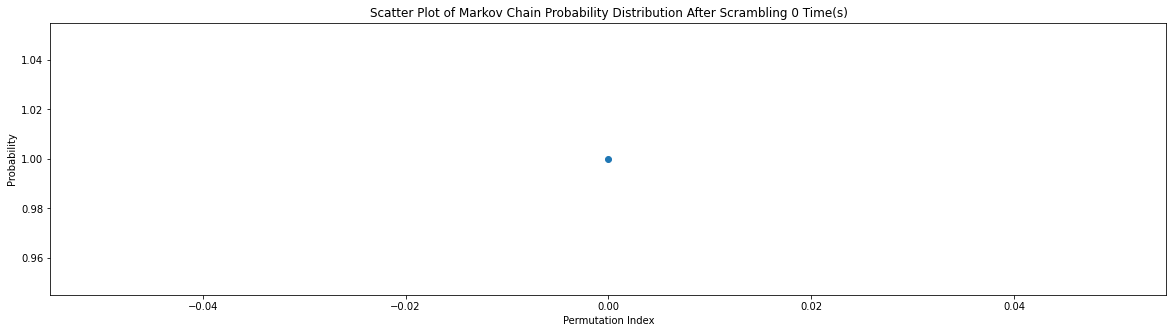

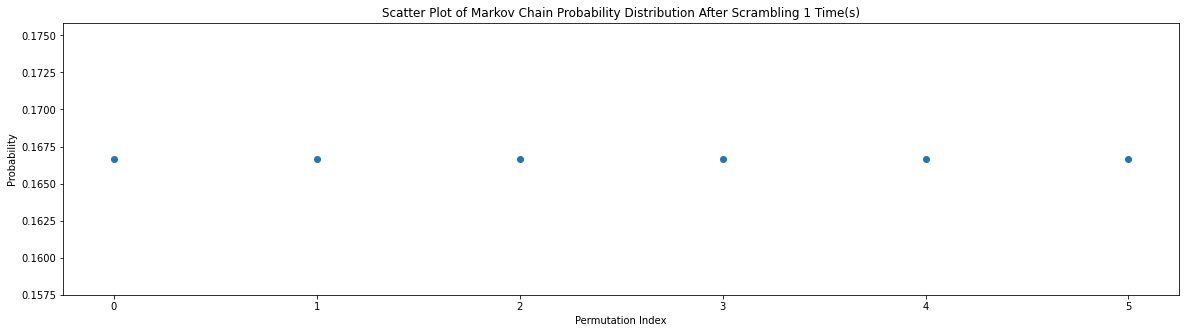

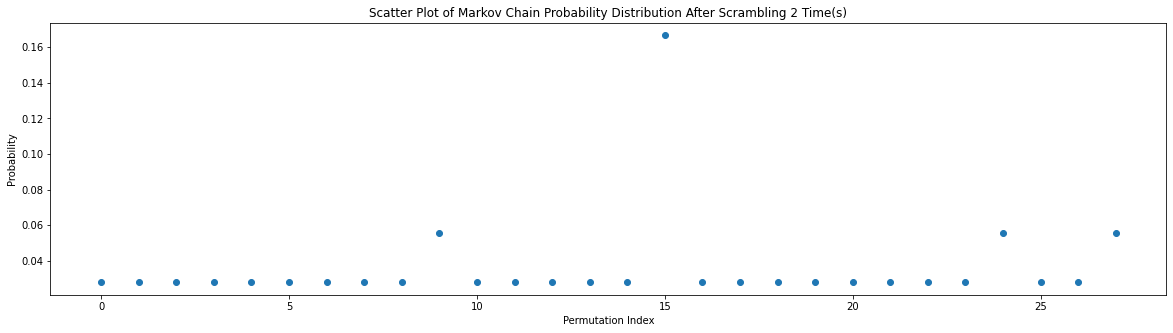

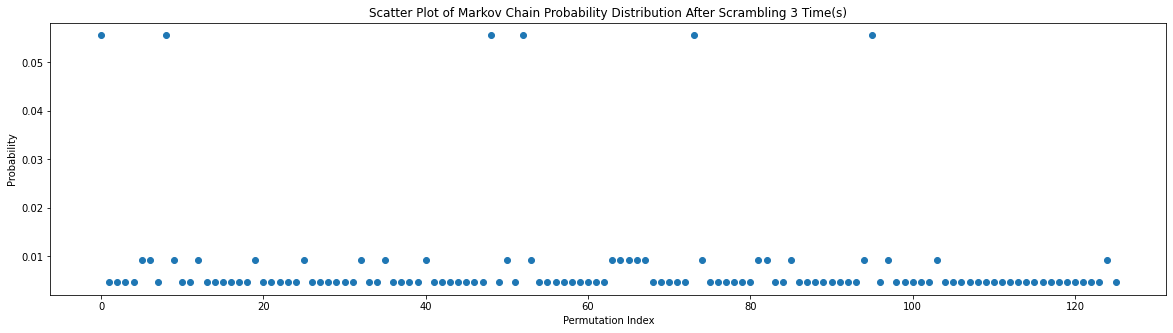

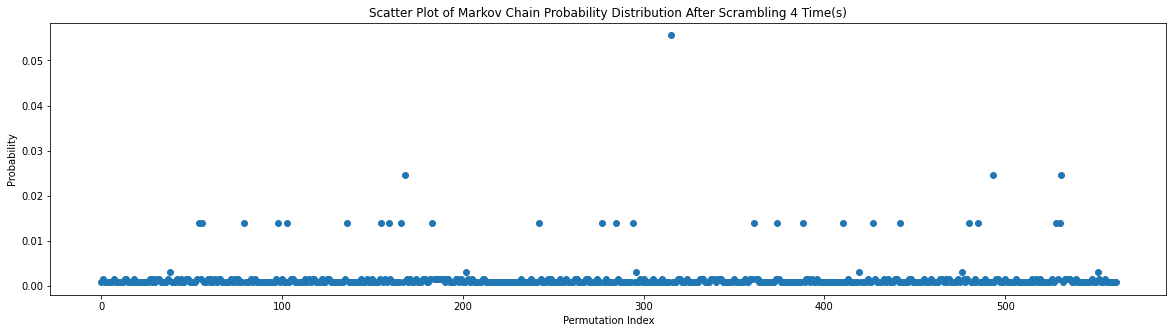

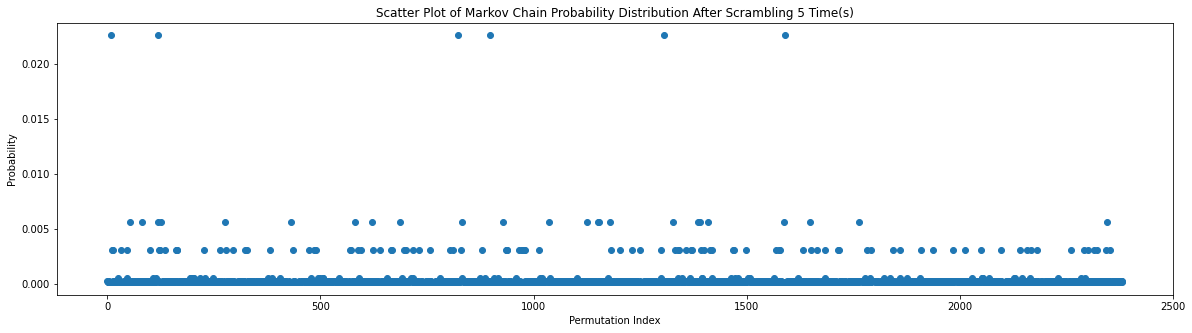

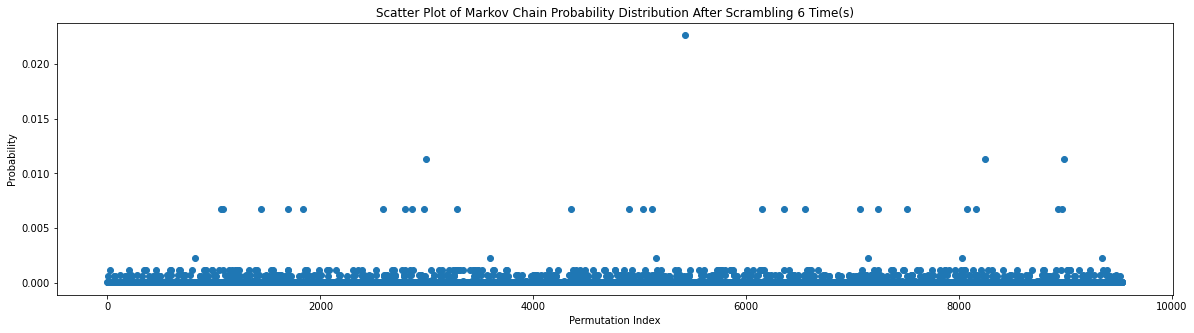

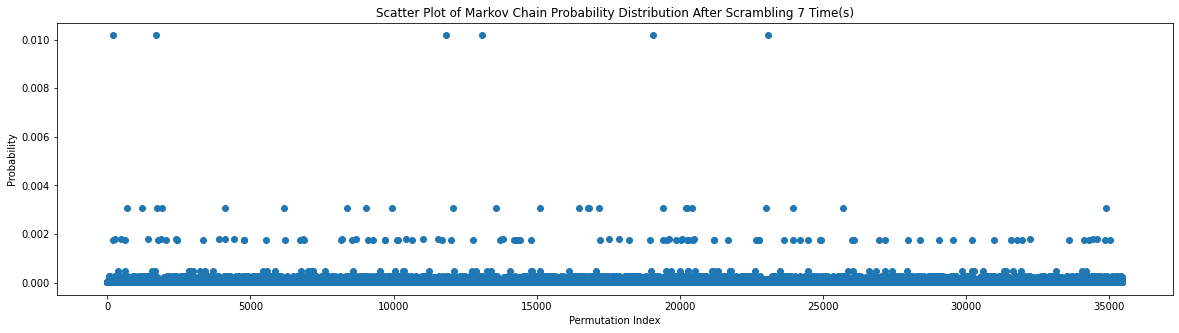

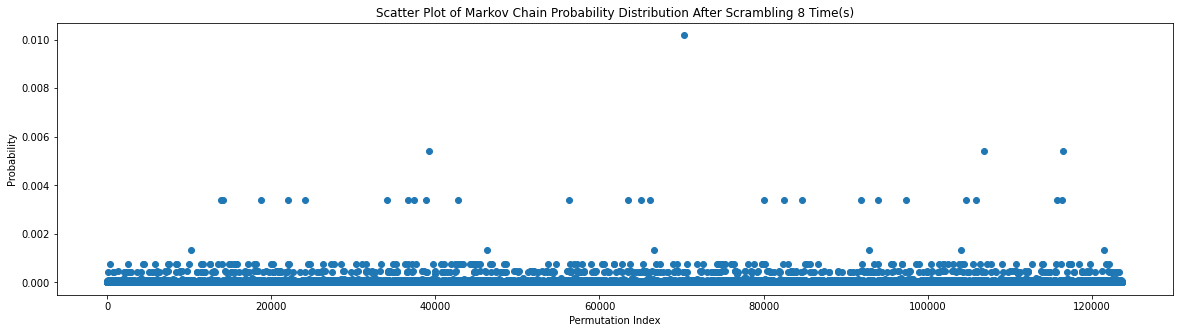

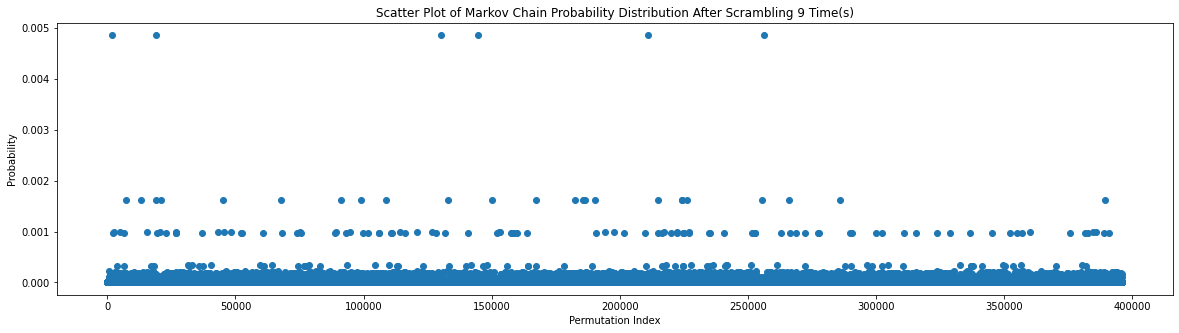

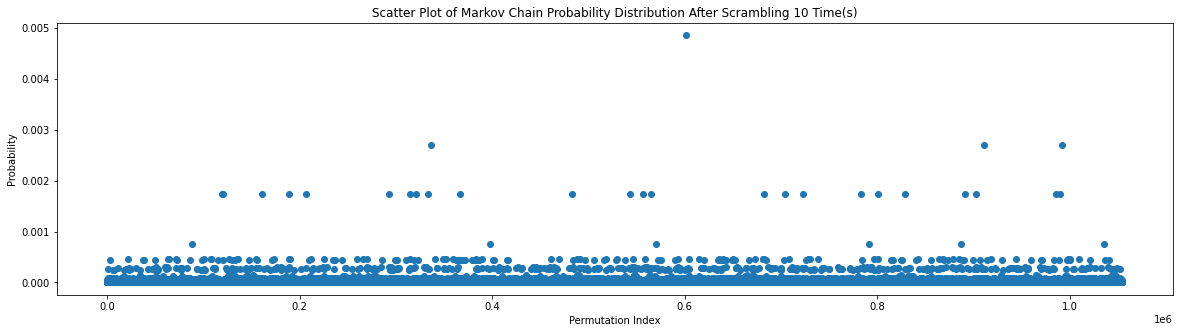

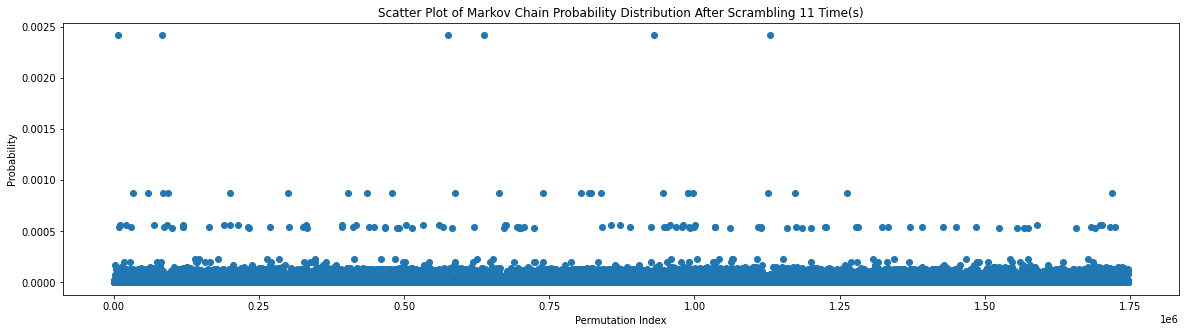

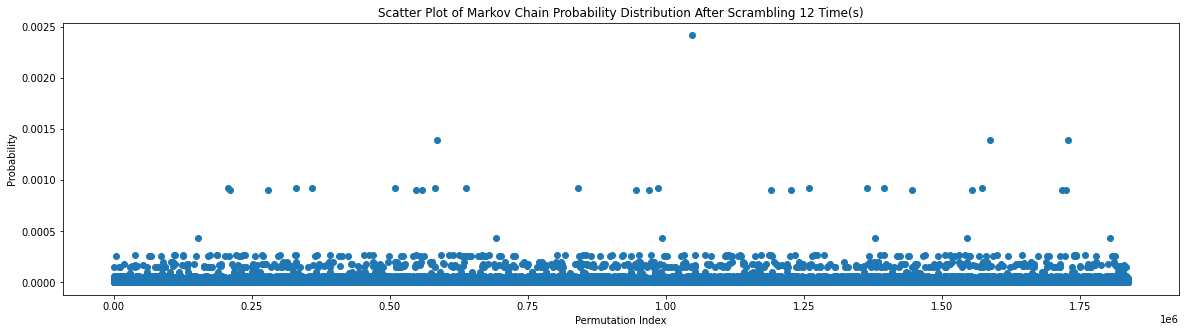

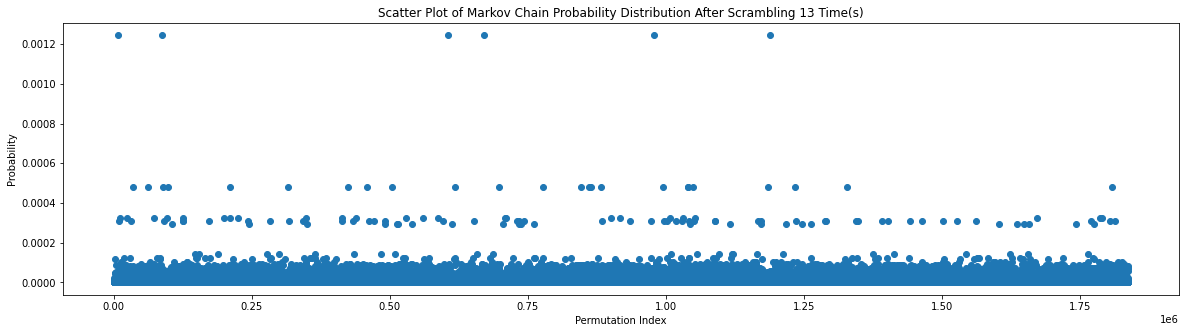

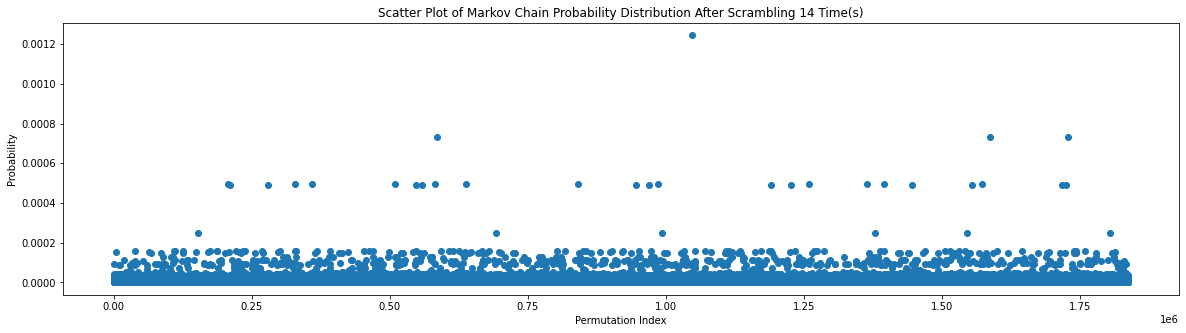

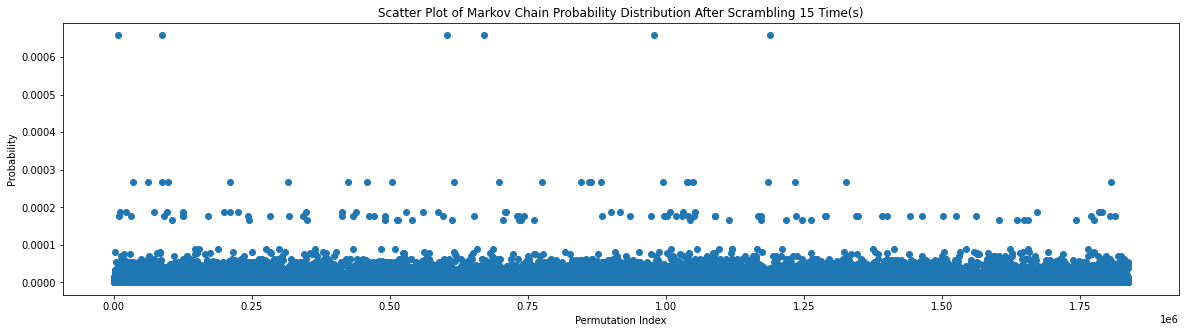

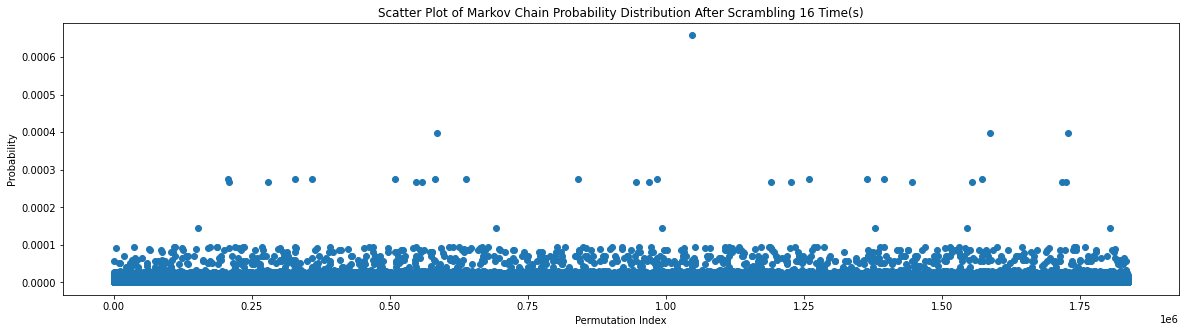

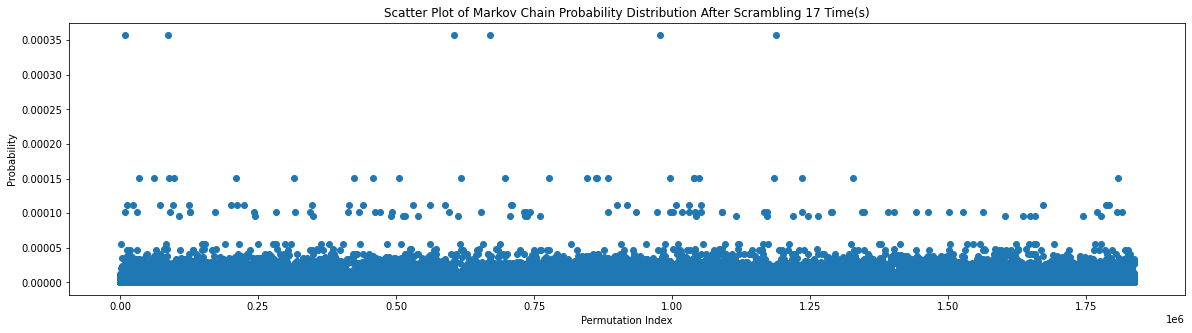

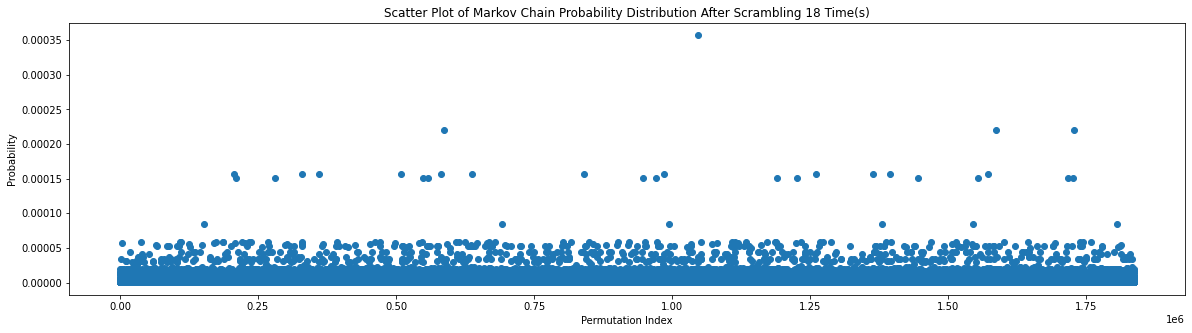

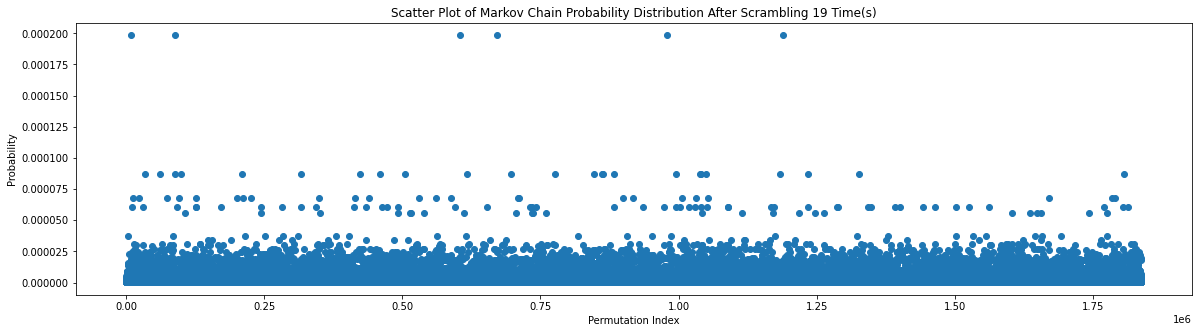

In [35]:
for t in range(20):
    pi=get_chain_distribution(n,transition_matrix,t)
    values=pi.data
    indices=range(len(values))
    fig,ax=plt.subplots(figsize=(20,5))
    ax.scatter(indices,pi.data)
    ax.set_xlabel('Permutation Index')
    ax.set_ylabel('Probability')
    ax.set_title('Scatter Plot of Markov Chain Probability Distribution After Scrambling {} Time(s)'.format(t))

# Total Variation Distance To Uniform
Consider the discrete uniform distribution $\pi_\infty$ on $\mathcal{G}_n,$ that is, $\pi_\infty(g)=1/N$ for each $g \in \mathcal{G}_n,$ where $N=|\mathcal{G}_n|$ as before. For each $t \in \mathbb{N},$ we compute the $\textbf{total variation distance}$ of $\pi_t$ to $\pi_\infty,$ which is the quantity
$$\text{TV}(\pi_t,\pi_\infty) = \frac{1}{2} \|\boldsymbol{\pi}_t - \boldsymbol{\pi}_\infty \|,$$ where $\boldsymbol{\pi}_\infty=(1/N, \ \dots \ , 1/N) \in \mathbb{R}^N.$

We show a plot of the total variation distances for $t \le 49.$ There is all the more evidence pointing towards it being theoretically impossible to scramble the cube. We conjecture based on simulation that $$\lim_{t \in \mathbb{N}}\text{TV}(\pi_t,\pi_\infty) = 1/2.$$

Text(0.5, 1.0, 'Scatter Plot of Markov Chain Total Variation Distances to Uniform After Scrambling')

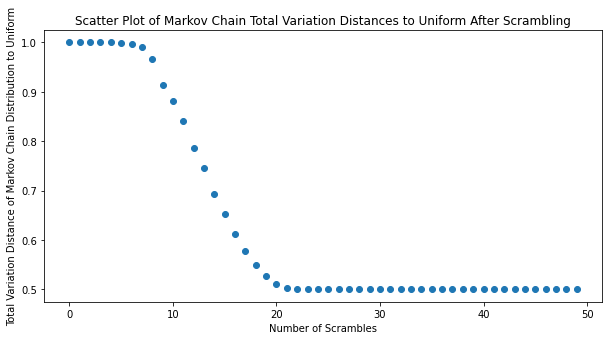

In [38]:
t=50
chain_dists=[get_chain_distribution(n,transition_matrix,j) for j in range(t)]
N=pi.shape[0]
tv_dists=[0.5*(np.linalg.norm(pi.data-1/N,1)+(N-len(pi.data))/N) for pi in chain_dists]
fig,ax=plt.subplots(figsize=(10,5))
ax.scatter(range(t),tv_dists)
ax.set_xlabel('Number of Scrambles')
ax.set_ylabel('Total Variation Distance of Markov Chain Distribution to Uniform')
ax.set_title('Scatter Plot of Markov Chain Total Variation Distances to Uniform After Scrambling')

# References

- https://www.lifehacker.com.au/2020/01/how-hard-is-it-to-scramble-rubiks-cube/
- http://anttila.ca/michael/devilsalgorithm/#:~:text=Definition%3A%20A%20Devil's%20Algorithm%20is,in%20the%20shortest%20Devil's%20Algorithm.